# **Imports and Libraries**

In [7]:
!pip install opencv-python
import os
import cv2
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_recall_curve
from scipy import stats

# **Image Preprocessing and Feature Extraction (Increased Features from 2 to 8)**

In [8]:
def preprocess_image(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"Image not found or cannot be loaded: {image_path}")
    _, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY_INV)
    return img, binary
# Added perimeter, Circularity, Aspect ratio, Extent ratio, Mean pixel intensity (darkness), Equivalent diameter
# increased features to increase accuracy
def extract_features(binary_image, original_image):
    contours, _ = cv2.findContours(binary_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    features = []
    for contour in contours:
        # Basic features
        area = cv2.contourArea(contour)
        perimeter = cv2.arcLength(contour, True)
        x, y, w, h = cv2.boundingRect(contour) 
        # Avoid division by zero
        if w * h == 0 or perimeter == 0:
            continue  
        # Solidity: ratio of contour area to bounding box area
        solidity = area / (w * h)
        # Circularity: how close the shape is to a perfect circle
        circularity = (4 * np.pi * area) / (perimeter ** 2) if perimeter > 0 else 0
        # Aspect ratio
        aspect_ratio = float(w) / h if h > 0 else 0
        # Extent: ratio of contour area to bounding rectangle area
        extent = area / (w * h)
        # Mean pixel intensity (darkness)
        mask = np.zeros(original_image.shape, dtype=np.uint8)
        cv2.drawContours(mask, [contour], -1, 255, -1)
        mean_intensity = cv2.mean(original_image, mask=mask)[0]
        # Equivalent diameter
        equiv_diameter = np.sqrt(4 * area / np.pi)
        features.append((area, solidity, circularity, aspect_ratio, extent, mean_intensity, equiv_diameter, perimeter))
    return features

def assign_label(solidity):
    if solidity > 0.40:
        return "Confidence"
    elif solidity > 0.178:
        return "Confusion"
    elif solidity > 0.01:
        return "Stress"
    else:
        return None

# **Load and Preprocess Images (Expanded Feature Support)**

In [9]:
def load_and_preprocess_images(image_folder):
    images = []
    labels = []
    filenames = []
    for root, _, files in os.walk(image_folder):
        for file in sorted(files):
            if file.lower().endswith(('.jpg', '.png')):
                image_path = os.path.join(root, file)
                # Get both original and binary for intensity extraction
                img, binary = preprocess_image(image_path)
                # Update: Pass 'img' to capture color/intensity features
                features = extract_features(binary, img)
                if not features:
                    print(f"Warning: No features found in {file}")
                for feature_set in features:
                    # Update: Unpack all 8 dimensions instead of just 2
                    area, solidity, circularity, aspect_ratio, extent, mean_intensity, equiv_diameter, perimeter = feature_set
                    label = assign_label(solidity)
                    if label is None:
                        continue      
                    images.append(feature_set)  # Update: Store complete 8-feature vector
                    labels.append(label)
                    filenames.append(file)
    
    return np.array(images), np.array(labels), filenames

# **Label Summary**

In [10]:
def label_summary(labels, filenames, label_encoder):
    original_labels = label_encoder.inverse_transform(labels)

    label_counts = {
        "Confidence": [],
        "Confusion": [],
        "Stress": []
    }

    for label, filename in zip(original_labels, filenames):
        
        label_counts[label].append(filename)

    print("Label Summary:")
    for label, files in label_counts.items():
        print(f"{label}: {len(files)} image(s)")
        if len(files) > 0:
            print(f"  {', '.join(files[:5])}...")

# **Exploratory Data Analysis (EDA) 8-Features**

Dataset Shape: (7288, 10)

              Area     Solidity  Circularity  AspectRatio       Extent  \
count  7288.000000  7288.000000  7288.000000  7288.000000  7288.000000   
mean    523.894827     0.415658     0.445186     1.142221     0.415658   
std     562.237453     0.263978     0.299443     1.032842     0.263978   
min       0.500000     0.010417     0.001667     0.166667     0.010417   
25%       4.500000     0.166667     0.161229     0.975000     0.166667   
50%     131.500000     0.333333     0.421450     1.000000     0.333333   
75%    1191.000000     0.726829     0.761473     1.025641     0.726829   
max    1622.500000     0.865313     0.915877    22.000000     0.865313   

       MeanIntensity  EquivDiameter    Perimeter  
count    7288.000000    7288.000000  7288.000000  
mean      104.493594      19.417219   111.174379  
std        21.171850      17.031002   104.985890  
min        32.933333       0.797885     3.414214  
25%        94.039966       2.393654    12.485281  


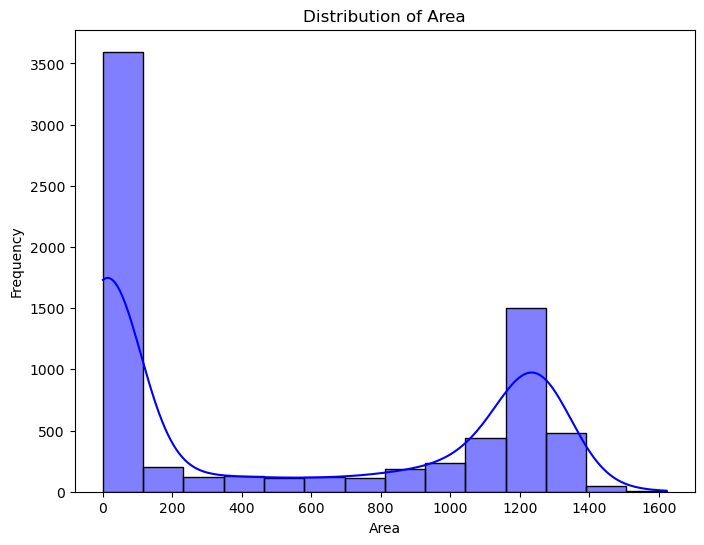

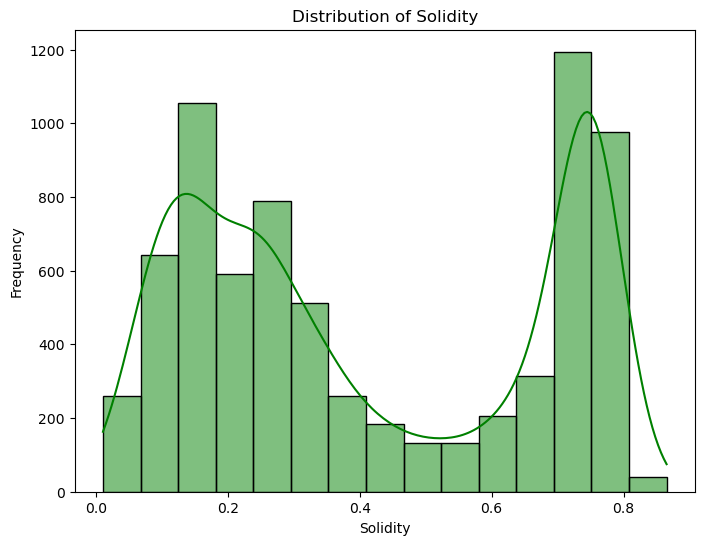

In [12]:
dataset_path = r'C:\Users\Malik.Umair\Desktop\NLP_Project\Test\Extracted_Circles_from_OMR\filled_circles'
images, labels, filenames = load_and_preprocess_images(dataset_path)

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(labels)

# Update: Extract all 8 features individually
areas = [feature[0] for feature in images]
solidities = [feature[1] for feature in images]
circularities = [feature[2] for feature in images]    # New
aspect_ratios = [feature[3] for feature in images]    # New
extents = [feature[4] for feature in images]          # New
mean_intensities = [feature[5] for feature in images] # New
equiv_diameters = [feature[6] for feature in images]  # New
perimeters = [feature[7] for feature in images]       # New

# Update: Build DataFrame with 10 columns (was 4)
df = pd.DataFrame({
    'Filename': filenames,
    'Area': areas,
    'Solidity': solidities,
    'Circularity': circularities,
    'AspectRatio': aspect_ratios,
    'Extent': extents,
    'MeanIntensity': mean_intensities,
    'EquivDiameter': equiv_diameters,
    'Perimeter': perimeters,
    'Label': labels
})

# Analysis
print("Dataset Shape:", df.shape)
print("\n" + "="*50)
print(df.describe()) # Update: Describes stats for all 8 features
print("\n" + "="*50)
print(df.head())
print("\n" + "="*50)
label_summary(y_encoded, filenames, label_encoder)

# Visualizations
plt.figure(figsize=(8, 6))
sns.histplot(df['Area'], kde=True, color='blue')
plt.title('Distribution of Area')
plt.xlabel('Area')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(8, 6))
sns.histplot(df['Solidity'], kde=True, color='green')
plt.title('Distribution of Solidity')
plt.xlabel('Solidity')
plt.ylabel('Frequency')
plt.show()

# **Bivariate Analysis 8 Features**

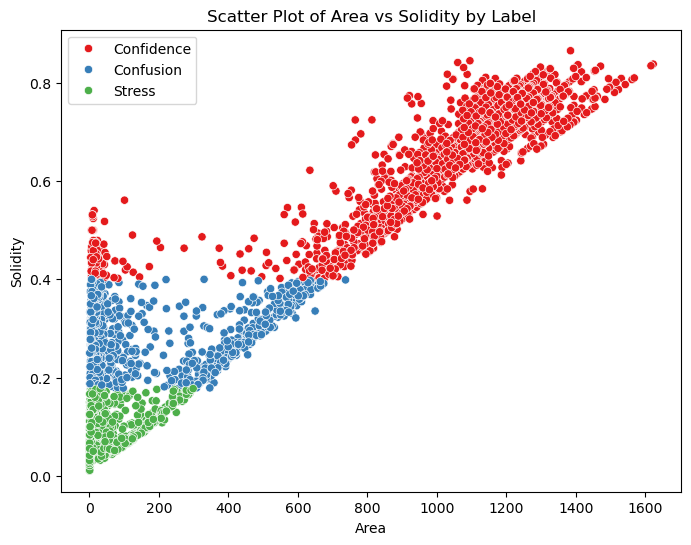

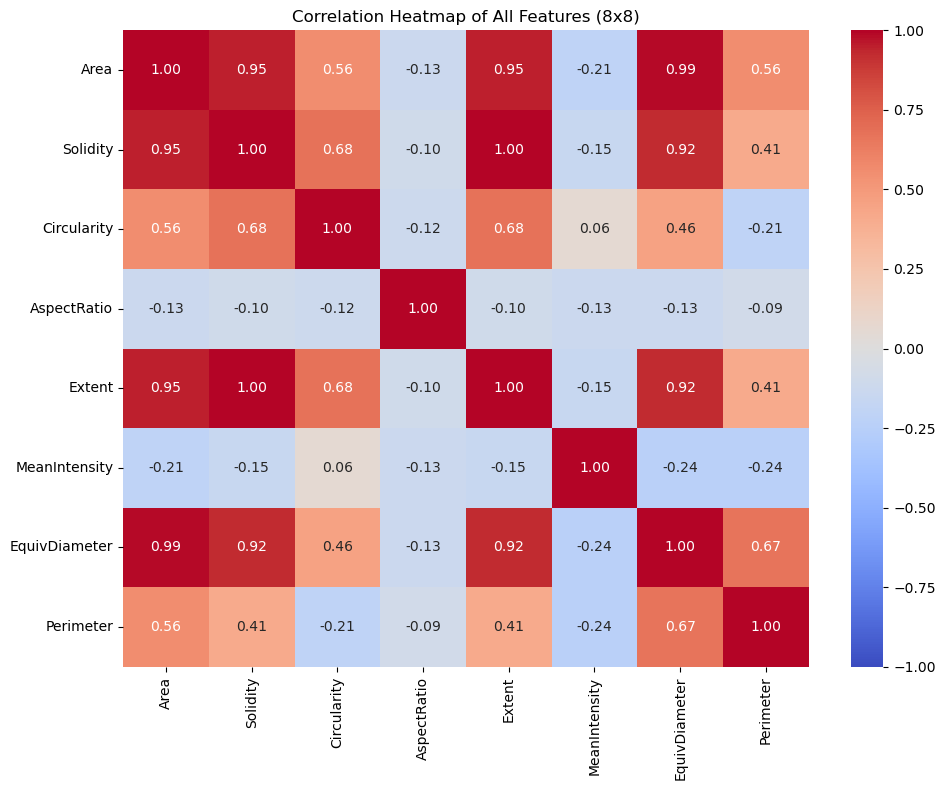

In [13]:
# 1. Scatter Plot: Visualizing Class Separation
# (Still using Area vs Solidity as primary visual, but derived from 8-feature DF)
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Area', y='Solidity', hue='Label', data=df, palette='Set1')
plt.title('Scatter Plot of Area vs Solidity by Label')
plt.xlabel('Area')
plt.ylabel('Solidity')
plt.legend()
plt.show()

# 2. Update: Full 8x8 Correlation Matrix
# Defining the comprehensive feature set
feature_cols = ['Area', 'Solidity', 'Circularity', 'AspectRatio', 
                'Extent', 'MeanIntensity', 'EquivDiameter', 'Perimeter']

correlation_matrix = df[feature_cols].corr()

plt.figure(figsize=(10, 8))
# Update: fmt='.2f' added for precision, larger canvas for readability
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.title('Correlation Heatmap of All Features (8x8)')
plt.tight_layout()
plt.show()

# **Statistical Tests**

In [14]:
stat_area, p_area = stats.shapiro(df['Area'])
stat_solidity, p_solidity = stats.shapiro(df['Solidity'])

print(f"Shapiro-Wilk test for 'Area': Statistic = {stat_area}, p-value = {p_area}")
print(f"Shapiro-Wilk test for 'Solidity': Statistic = {stat_solidity}, p-value = {p_solidity}")

anova_area = stats.f_oneway(df[df['Label'] == 'Confidence']['Area'],
                            df[df['Label'] == 'Confusion']['Area'],
                            df[df['Label'] == 'Stress']['Area'],
                            df[df['Label'] == 'Not Relevant']['Area'])
print(f"ANOVA test for 'Area' by Label: {anova_area}")

anova_solidity = stats.f_oneway(df[df['Label'] == 'Confidence']['Solidity'],
                                df[df['Label'] == 'Confusion']['Solidity'],
                                df[df['Label'] == 'Stress']['Solidity'],
                                df[df['Label'] == 'Not Relevant']['Solidity'])
print(f"ANOVA test for 'Solidity' by Label: {anova_solidity}")

Shapiro-Wilk test for 'Area': Statistic = 0.7506292244215966, p-value = 4.134993932172565e-74
Shapiro-Wilk test for 'Solidity': Statistic = 0.8625942059837439, p-value = 3.94214771626221e-62
ANOVA test for 'Area' by Label: F_onewayResult(statistic=np.float64(nan), pvalue=np.float64(nan))
ANOVA test for 'Solidity' by Label: F_onewayResult(statistic=np.float64(nan), pvalue=np.float64(nan))


C:\Users\Malik.Umair\AppData\Local\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 7288.
  res = hypotest_fun_out(*samples, **kwds)
C:\Users\Malik.Umair\AppData\Local\Temp\ipykernel_17196\3362822184.py:7: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  anova_area = stats.f_oneway(df[df['Label'] == 'Confidence']['Area'],
C:\Users\Malik.Umair\AppData\Local\Temp\ipykernel_17196\3362822184.py:13: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  anova_solidity = stats.f_oneway(df[df['Label'] == 'Confidence']['Solidity'],


# **Feature Scaling (8 Features)**

In [15]:
# Define the comprehensive feature list
feature_cols = ['Area', 'Solidity', 'Circularity', 'AspectRatio', 
                'Extent', 'MeanIntensity', 'EquivDiameter', 'Perimeter']

scaler = StandardScaler()

# Update: Scale all 8 features simultaneously (formerly just Area/Solidity)
df[feature_cols] = scaler.fit_transform(df[feature_cols])

print("Scaled Data (First 5 Rows):")
print(df[feature_cols].head())

Scaled Data (First 5 Rows):
       Area  Solidity  Circularity  AspectRatio    Extent  MeanIntensity  \
0  1.294213  1.388582     1.528425    -0.137708  1.388582      -1.861328   
1  1.311111  1.338252     1.365020    -0.161325  1.338252      -1.611774   
2  1.291545  1.242414     1.439961    -0.137708  1.242414      -1.601741   
3  1.316447  1.206140     1.472741    -0.114092  1.206140      -0.710378   
4  1.367141  1.268841     1.461562    -0.160762  1.268841      -2.476536   

   EquivDiameter  Perimeter  
0       1.203825   0.198215  
1       1.212705   0.238630  
2       1.202420   0.216309  
3       1.215502   0.216309  
4       1.241911   0.233049  


# **Class Imbalance**

C:\Users\Malik.Umair\AppData\Local\Temp\ipykernel_17196\3797020279.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Label', data=df, palette='Set2')


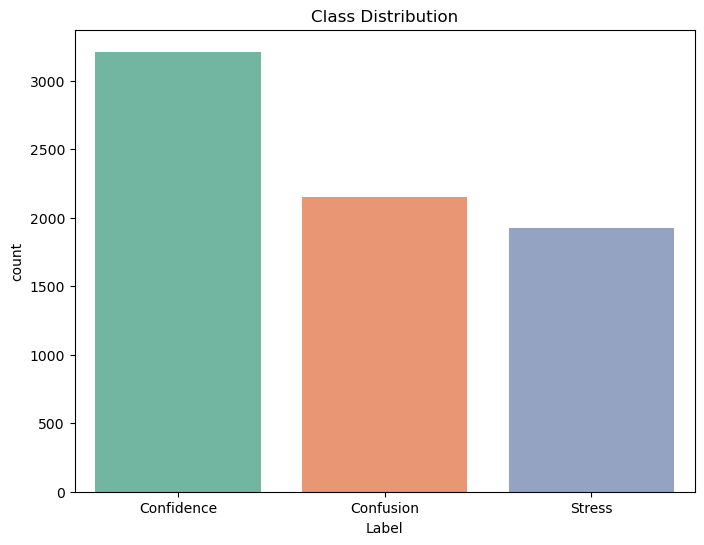

In [16]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Label', data=df, palette='Set2')
plt.title('Class Distribution')
plt.show()

# **Train Model and Evaluation (With Scaled Data)**

C:\Users\Malik.Umair\AppData\Local\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Accuracy: 0.97
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.97      0.98       687
           1       0.94      0.95      0.95       414
           2       0.96      1.00      0.98       357

    accuracy                           0.97      1458
   macro avg       0.97      0.97      0.97      1458
weighted avg       0.97      0.97      0.97      1458



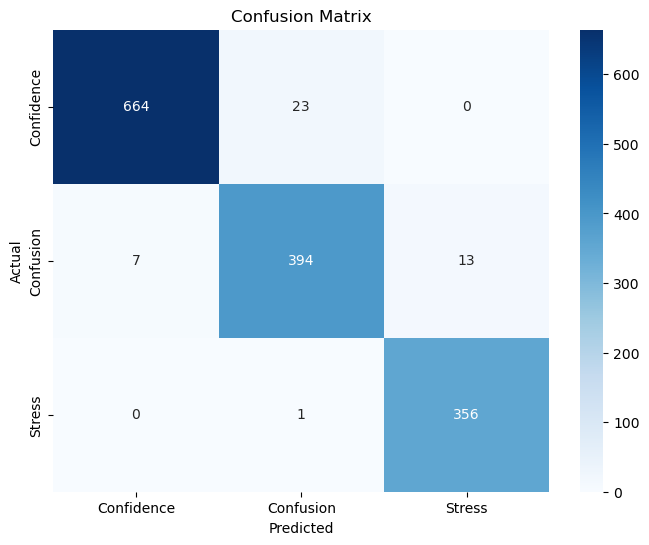

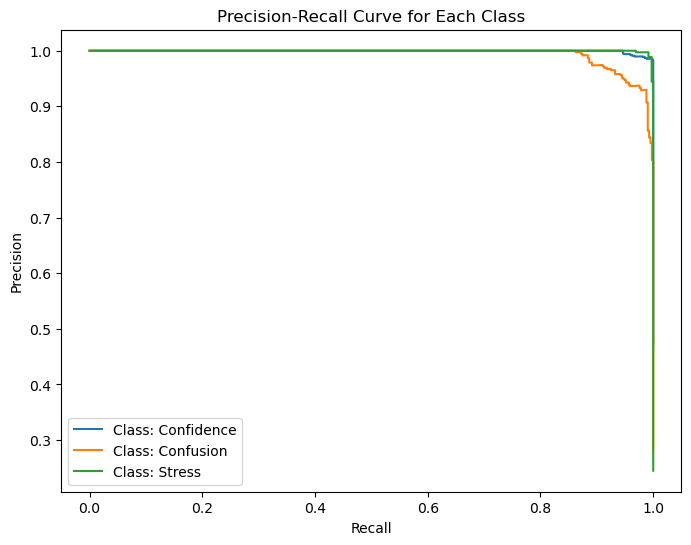

In [17]:
dataset_path = r'C:\Users\Malik.Umair\Desktop\NLP_Project\Test\Extracted_Circles_from_OMR\filled_circles'

X, y, filenames = load_and_preprocess_images(dataset_path)

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Scale the features
scaler_model = StandardScaler()
X_scaled = scaler_model.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=1000, multi_class='ovr', solver='lbfgs')
model.fit(X_train, y_train)

predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)
report = classification_report(y_test, predictions)

print(f"Accuracy: {accuracy:.2f}")
print("Classification Report:\n", report)

cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

y_proba = model.predict_proba(X_test)

plt.figure(figsize=(8, 6))
for i, label in enumerate(label_encoder.classes_):
    precision, recall, _ = precision_recall_curve(y_test == i, y_proba[:, i])
    plt.plot(recall, precision, label=f'Class: {label}')

plt.title('Precision-Recall Curve for Each Class')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.show()

# **Predicting Label for Images**

In [24]:
def result(test_path):

    # Preprocess the single image
    img, binary = preprocess_image(test_path)
    features = extract_features(binary)

    if not features:
        raise ValueError("No features found in the image.")

    # Assuming the first feature set is representative
    area, solidity = features[0]

    # Scale the features
    scaled_features = scaler.transform([[area, solidity]])

    # Predict the label
    predicted_label_encoded = model.predict(scaled_features)
    predicted_label = label_encoder.inverse_transform(predicted_label_encoded)

    print(f"Predicted label for the image '{test_path}': {predicted_label[0]}")
    
    plt.imshow(img, cmap='gray')  # Show the image
    plt.title(f"Predicted label: {predicted_label}")
    plt.axis('off')
    plt.show()

In [11]:
from Bubbles import extract_circles
from anotherBubbles import classify_circles

test_folder = r'C:\Users\Malik.Umair\Desktop\NLP_Project\Test'
output_circles_folder = rf'{test_folder}\Extracted_Circles_from_OMR'

print("Starting circle extraction...")
extract_circles(test_folder, output_circles_folder)

print("Starting circle classification...")
classify_circles(output_circles_folder)

filled = r"C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles"

Starting circle extraction...
1 C:\Users\Malik.Umair\Desktop\NLP_Project\Test\OMR - 01 - 48 sheets_Page_01.jpg
Saved circle 1 to C:\Users\Malik.Umair\Desktop\NLP_Project\Test\Extracted_Circles_from_OMR\circle2_1.png
Saved circle 2 to C:\Users\Malik.Umair\Desktop\NLP_Project\Test\Extracted_Circles_from_OMR\circle2_2.png
Saved circle 3 to C:\Users\Malik.Umair\Desktop\NLP_Project\Test\Extracted_Circles_from_OMR\circle2_3.png
Saved circle 4 to C:\Users\Malik.Umair\Desktop\NLP_Project\Test\Extracted_Circles_from_OMR\circle2_4.png
Saved circle 5 to C:\Users\Malik.Umair\Desktop\NLP_Project\Test\Extracted_Circles_from_OMR\circle2_5.png
Saved circle 6 to C:\Users\Malik.Umair\Desktop\NLP_Project\Test\Extracted_Circles_from_OMR\circle2_6.png
Saved circle 7 to C:\Users\Malik.Umair\Desktop\NLP_Project\Test\Extracted_Circles_from_OMR\circle2_7.png
Saved circle 8 to C:\Users\Malik.Umair\Desktop\NLP_Project\Test\Extracted_Circles_from_OMR\circle2_8.png
Saved circle 9 to C:\Users\Malik.Umair\Desktop\NL

Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle2_111.png': Confusion


c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


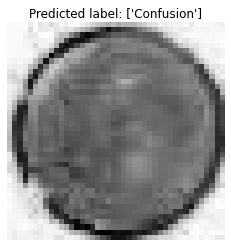

c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle2_112.png': Confusion


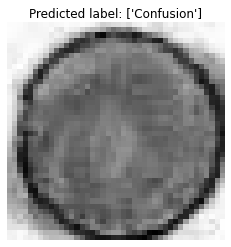

Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle2_116.png': Confusion


c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


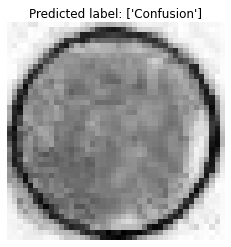

c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle2_117.png': Confusion


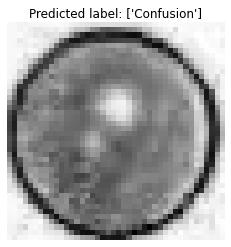

Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle2_120.png': Confusion


c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


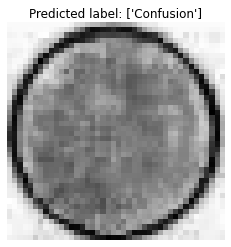

Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle2_128.png': Confusion


c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


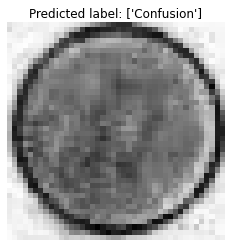

c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle2_135.png': Confusion


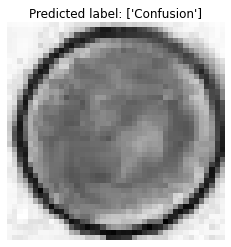

Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle2_149.png': Stress


c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


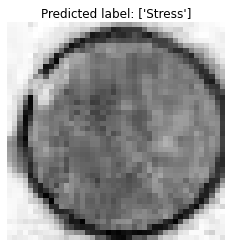

c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle2_154.png': Confusion


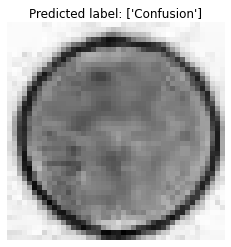

Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle2_155.png': Stress


c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


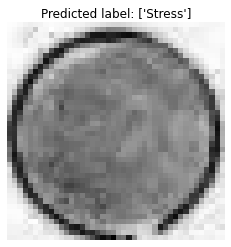

c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle2_162.png': Stress


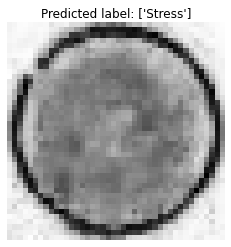

Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle2_169.png': Stress


c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


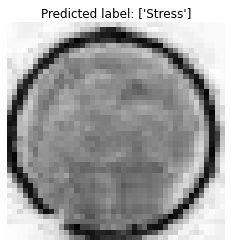

c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle2_172.png': Confusion


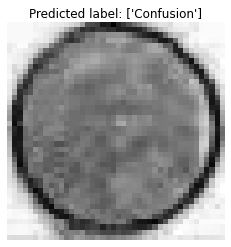

Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle2_175.png': Confusion


c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


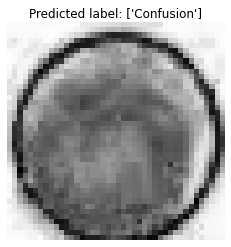

c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle2_177.png': Confusion


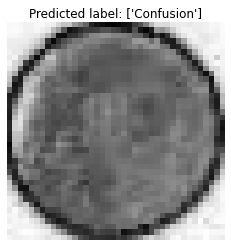

c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle2_183.png': Confusion


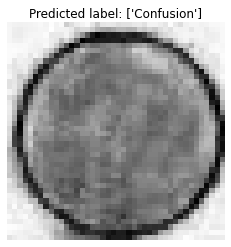

c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle2_187.png': Stress


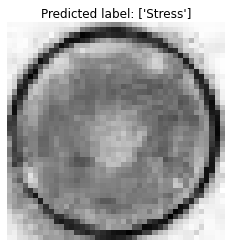

Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle2_193.png': Confusion


c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


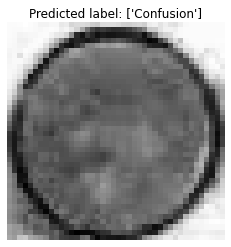

c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle2_196.png': Confusion


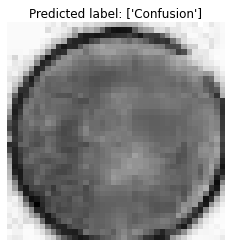

Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle2_197.png': Confusion


c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


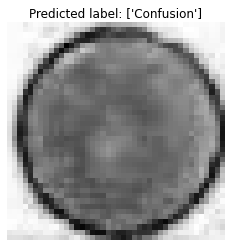

c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle2_20.png': Confusion


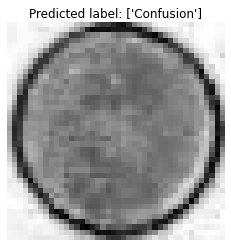

Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle2_204.png': Stress


c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


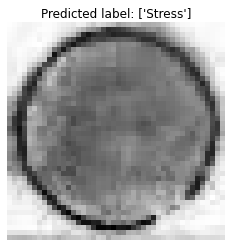

c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle2_215.png': Confusion


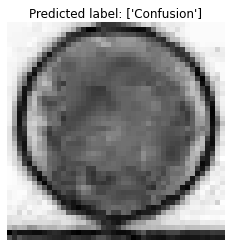

c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle2_216.png': Stress


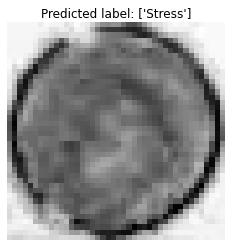

Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle2_222.png': Stress


c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


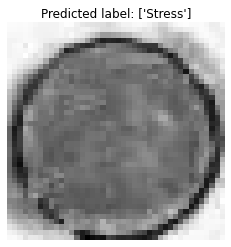

c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle2_225.png': Stress


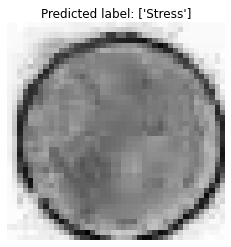

c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle2_226.png': Confusion


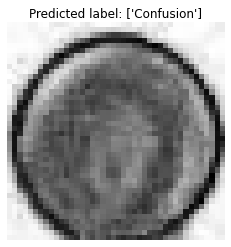

c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle2_230.png': Stress


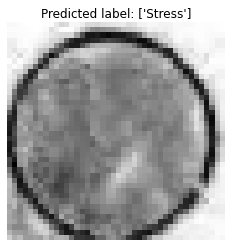

c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle2_234.png': Stress


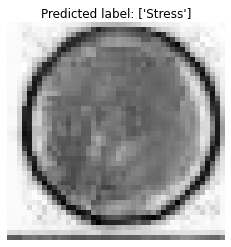

c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle2_235.png': Stress


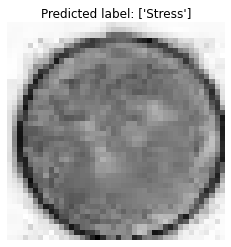

Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle2_236.png': Confusion


c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


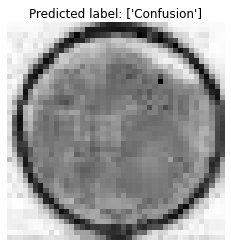

c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle2_237.png': Confusion


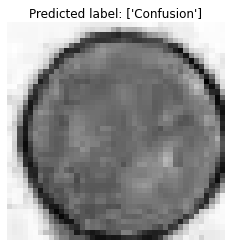

Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle2_239.png': Stress


c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


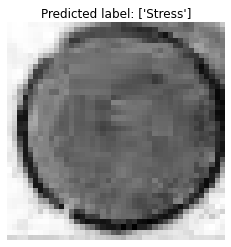

c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle2_240.png': Confusion


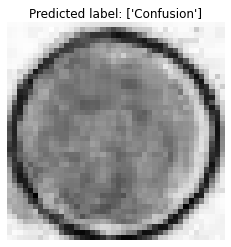

c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle2_241.png': Stress


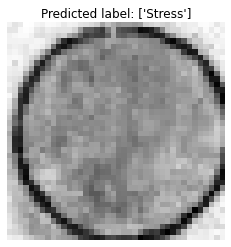

Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle2_244.png': Confusion


c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


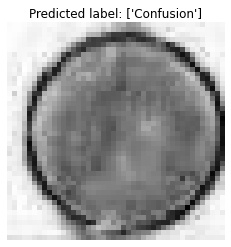

Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle2_245.png': Confusion


c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


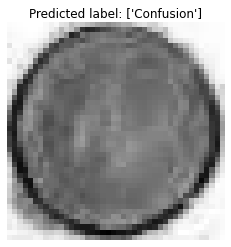

c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle2_248.png': Stress


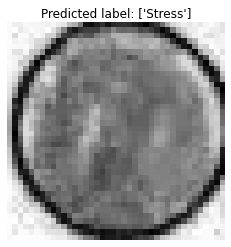

c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle2_249.png': Stress


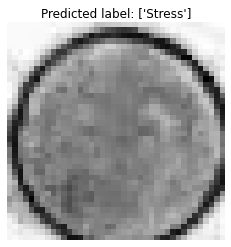

c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle2_45.png': Stress


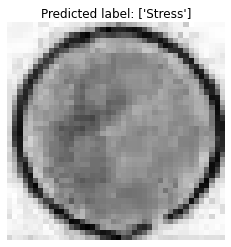

Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle2_60.png': Confusion


c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


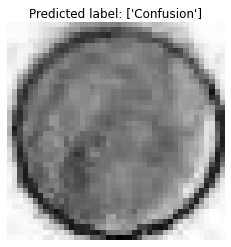

c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle2_77.png': Stress


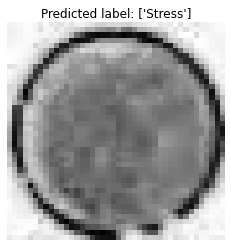

Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle2_84.png': Confusion


c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


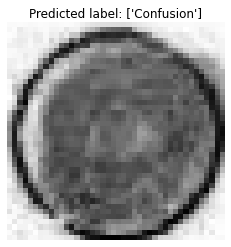

c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle2_92.png': Stress


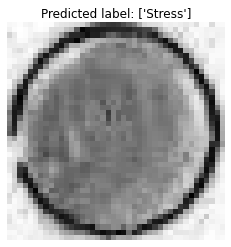

Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle2_99.png': Confusion


c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


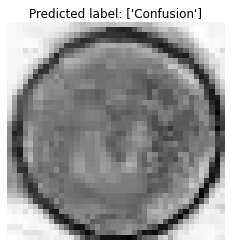

c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle3_103.png': Confusion


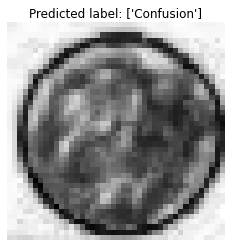

Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle3_104.png': Confusion


c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


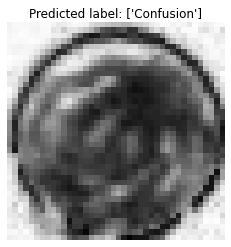

c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle3_105.png': Stress


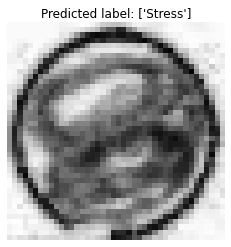

c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle3_106.png': Confusion


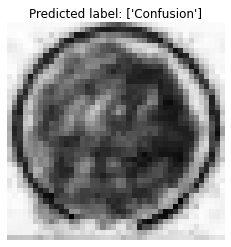

Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle3_114.png': Confusion


c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


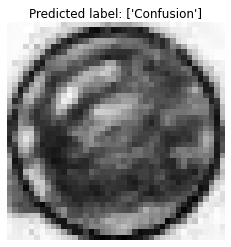

c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle3_116.png': Stress


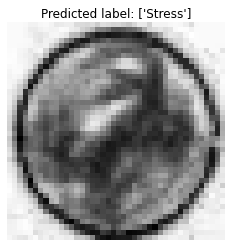

Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle3_118.png': Stress


c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


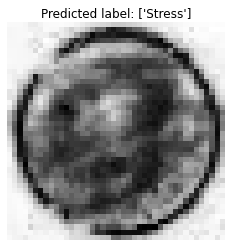

c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle3_125.png': Confusion


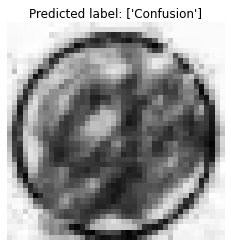

Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle3_128.png': Confusion


c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


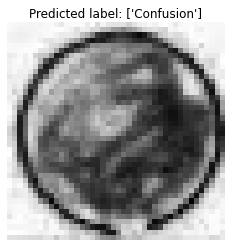

c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle3_129.png': Stress


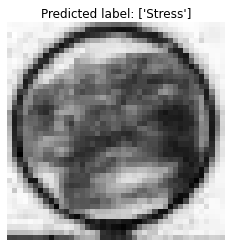

c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle3_130.png': Confusion


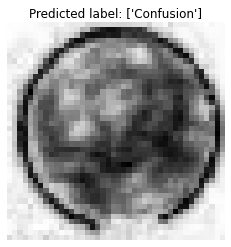

Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle3_131.png': Stress


c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


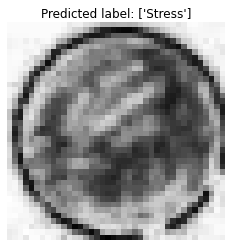

Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle3_132.png': Stress


c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


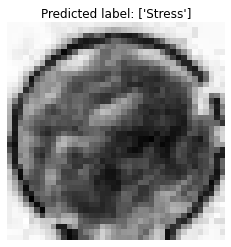

c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle3_137.png': Confusion


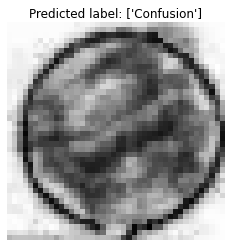

Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle3_140.png': Confusion


c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


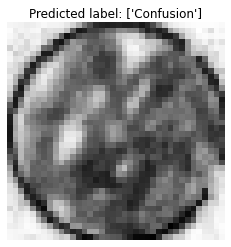

c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle3_144.png': Confusion


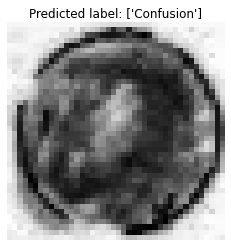

c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle3_146.png': Stress


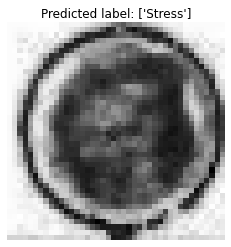

Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle3_148.png': Confusion


c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


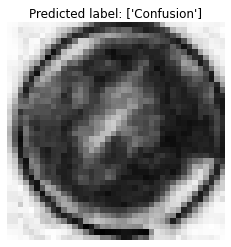

Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle3_149.png': Stress


c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


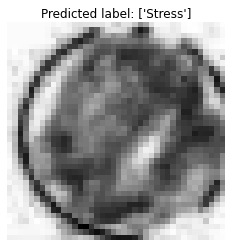

c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle3_155.png': Confusion


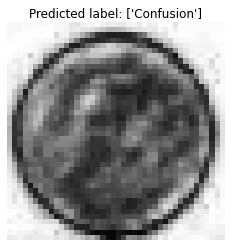

c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle3_158.png': Confusion


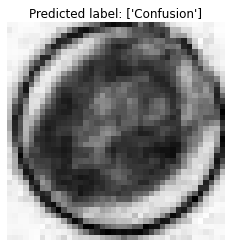

c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle3_165.png': Confusion


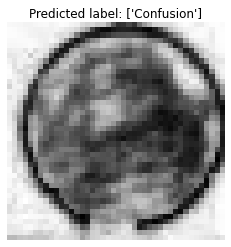

Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle3_167.png': Confusion


c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


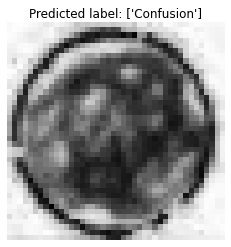

Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle3_169.png': Confusion


c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


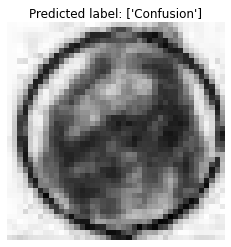

Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle3_183.png': Stress


c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


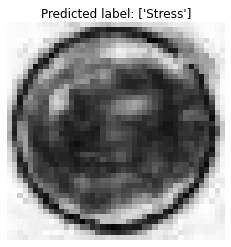

c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle3_188.png': Confusion


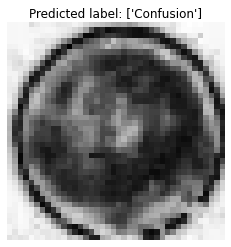

Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle3_194.png': Confusion


c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


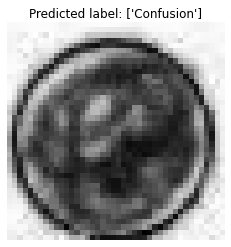

c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle3_195.png': Stress


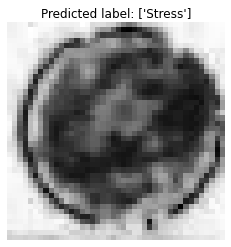

c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle3_201.png': Confusion


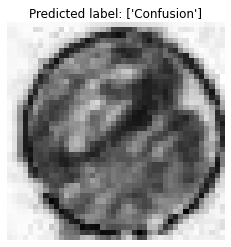

Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle3_209.png': Stress


c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


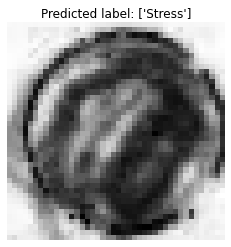

c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle3_222.png': Stress


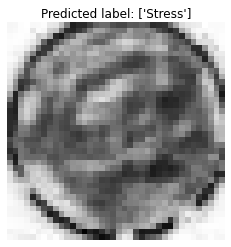

c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle3_223.png': Stress


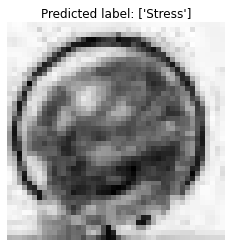

Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle3_224.png': Stress


c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


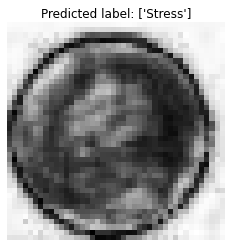

Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle3_226.png': Confusion


c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


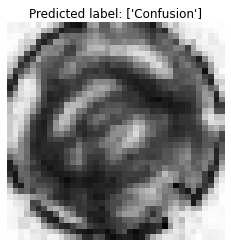

c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle3_31.png': Confusion


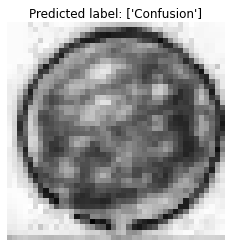

Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle3_36.png': Confusion


c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


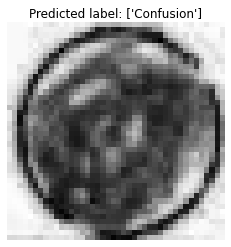

c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle3_50.png': Stress


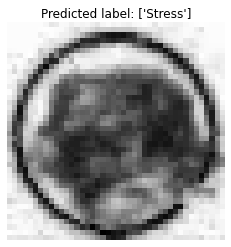

Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle3_52.png': Stress


c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


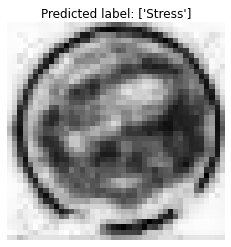

c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle3_57.png': Confusion


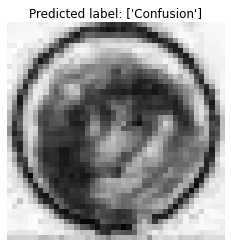

Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle3_64.png': Confusion


c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


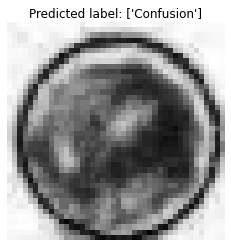

c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle3_65.png': Confusion


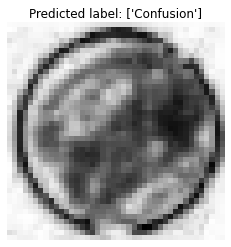

c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle3_68.png': Stress


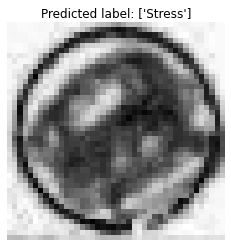

Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle3_69.png': Stress


c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


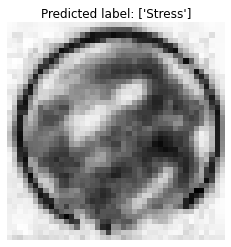

Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle3_84.png': Confusion


c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


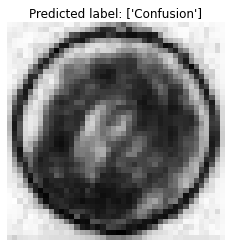

c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle3_90.png': Confusion


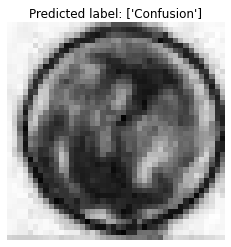

c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle3_95.png': Stress


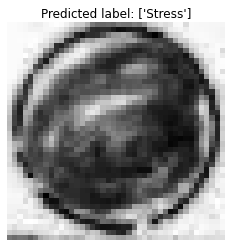

Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle3_99.png': Confusion


c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


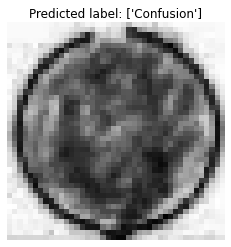

Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle4_102.png': Confusion


c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


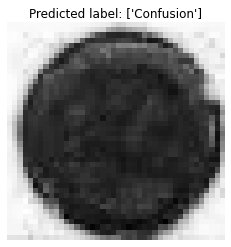

c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle4_114.png': Confusion


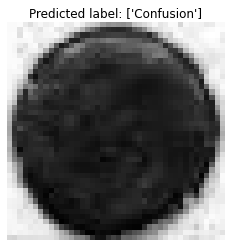

c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle4_116.png': Confusion


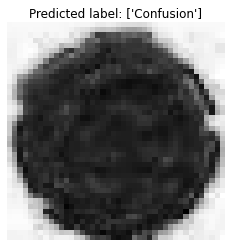

Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle4_121.png': Confusion


c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


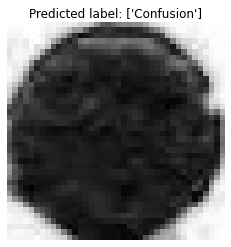

c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle4_122.png': Confusion


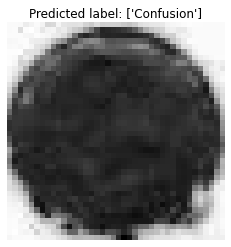

Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle4_123.png': Confusion

c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


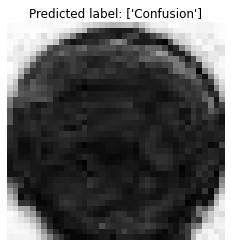

c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle4_134.png': Confusion


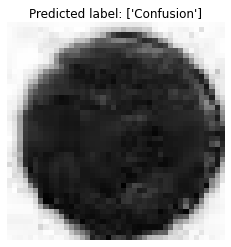

Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle4_135.png': Confusion


c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


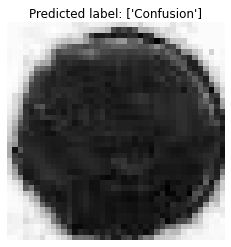

Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle4_136.png': Confusion


c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


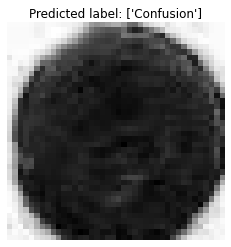

Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle4_141.png': Confusion


c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


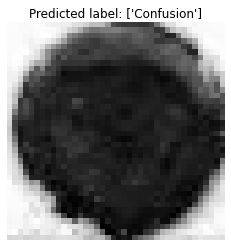

c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle4_146.png': Confusion


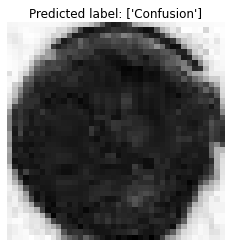

Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle4_154.png': Confusion


c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


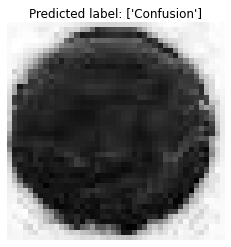

Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle4_16.png': Confusion


c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


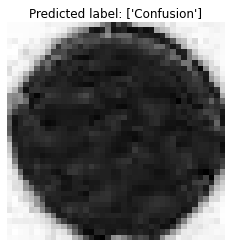

c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle4_168.png': Confusion


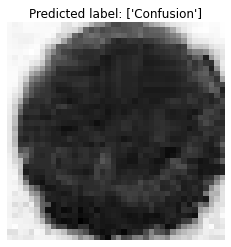

Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle4_173.png': Confusion


c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


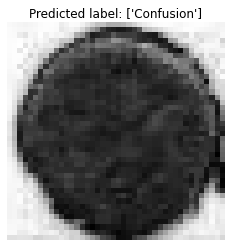

c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle4_174.png': Confusion


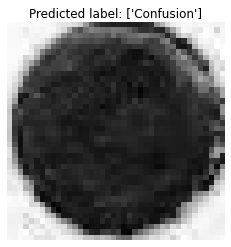

c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle4_177.png': Confusion


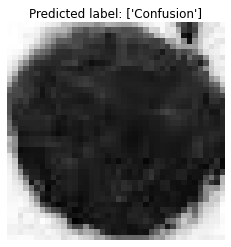

Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle4_179.png': Stress


c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


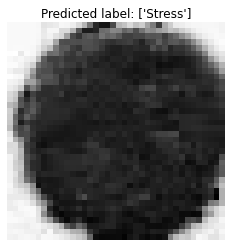

c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle4_184.png': Confusion


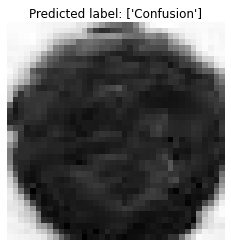

Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle4_196.png': Confusion


c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


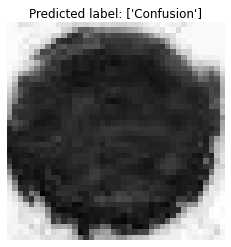

c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle4_199.png': Confusion


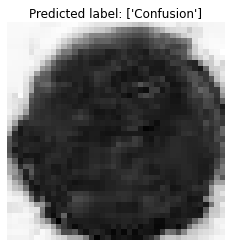

c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle4_2.png': Confusion


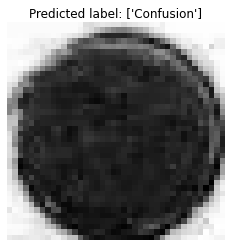

c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle4_204.png': Confusion


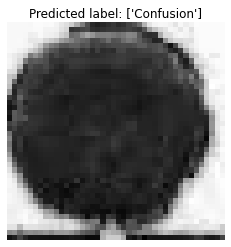

Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle4_209.png': Confusion


c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


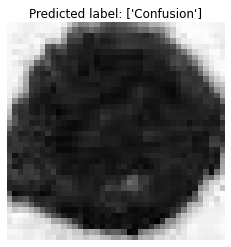

c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle4_211.png': Confusion


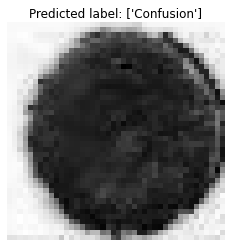

Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle4_212.png': Confusion


c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


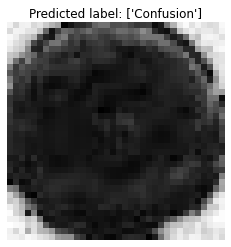

c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle4_216.png': Confusion


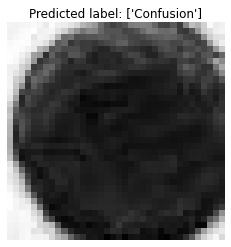

Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle4_24.png': Confusion


c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


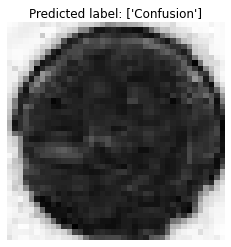

c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle4_34.png': Confusion


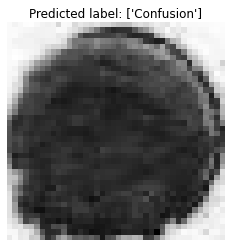

Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle4_36.png': Confusion


c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


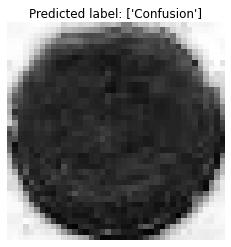

c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle4_46.png': Confusion


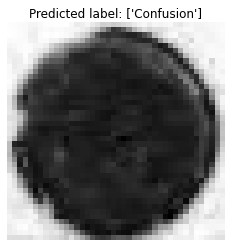

c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle4_57.png': Confusion


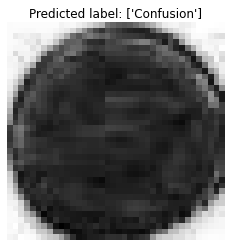

Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle4_62.png': Confusion


c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


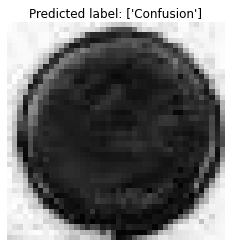

Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle4_71.png': Confusion


c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


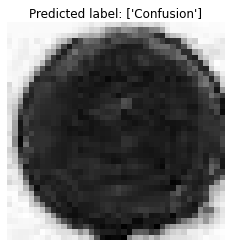

c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle4_75.png': Confusion


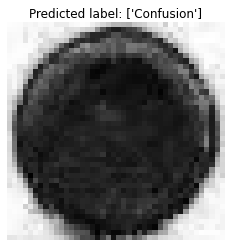

c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle4_82.png': Confusion


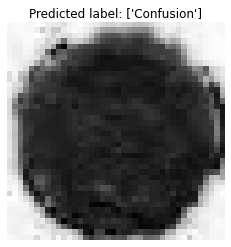

c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle4_83.png': Confusion


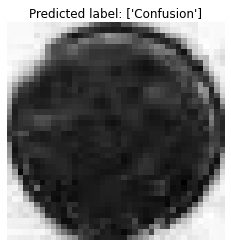

Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle4_84.png': Confusion


c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


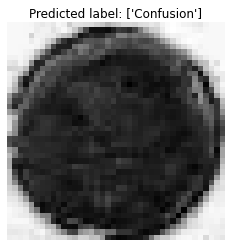

c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle4_90.png': Confusion


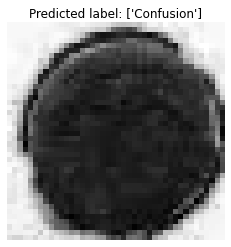

c:\Users\Laptop\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Predicted label for the image 'C:\Users\Laptop\test\Extracted_Circles_from_OMR\filled_circles\circle4_92.png': Confusion


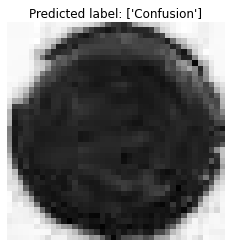

In [28]:
for each_circle in os.listdir(filled):
    result(os.path.join(filled, each_circle))
    # print(each_circle)